../Data_Sailnjord/Hyères November 2025/Maneuvers\30_11_2025\Gian\30_11_2025_Run11


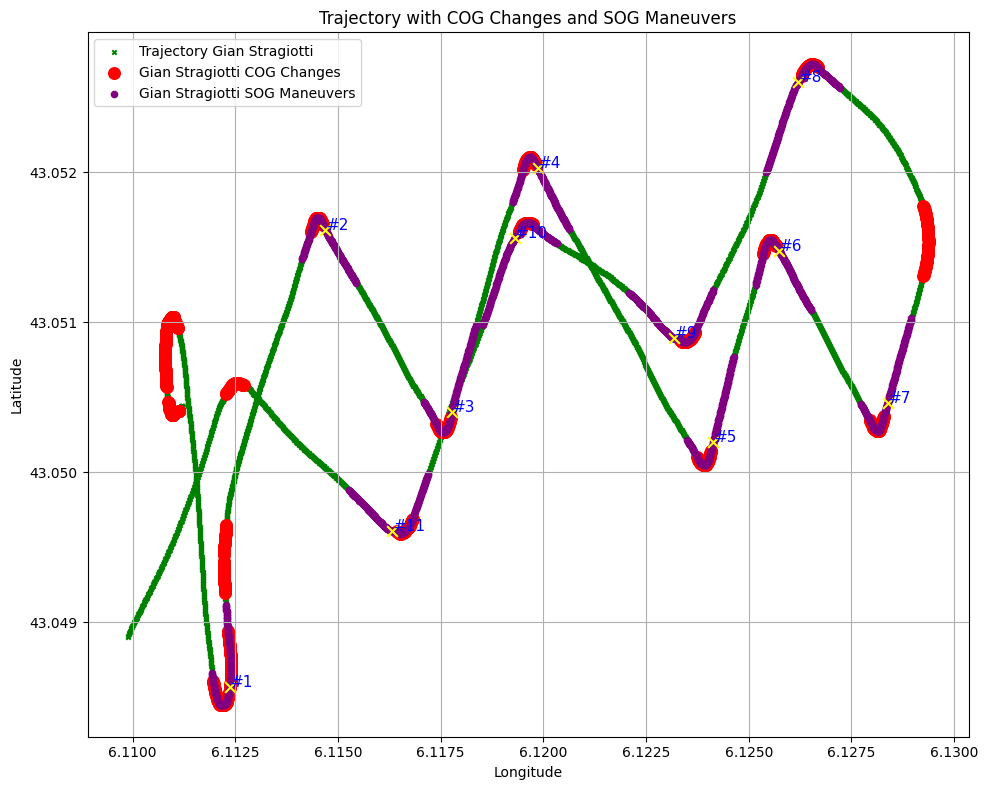

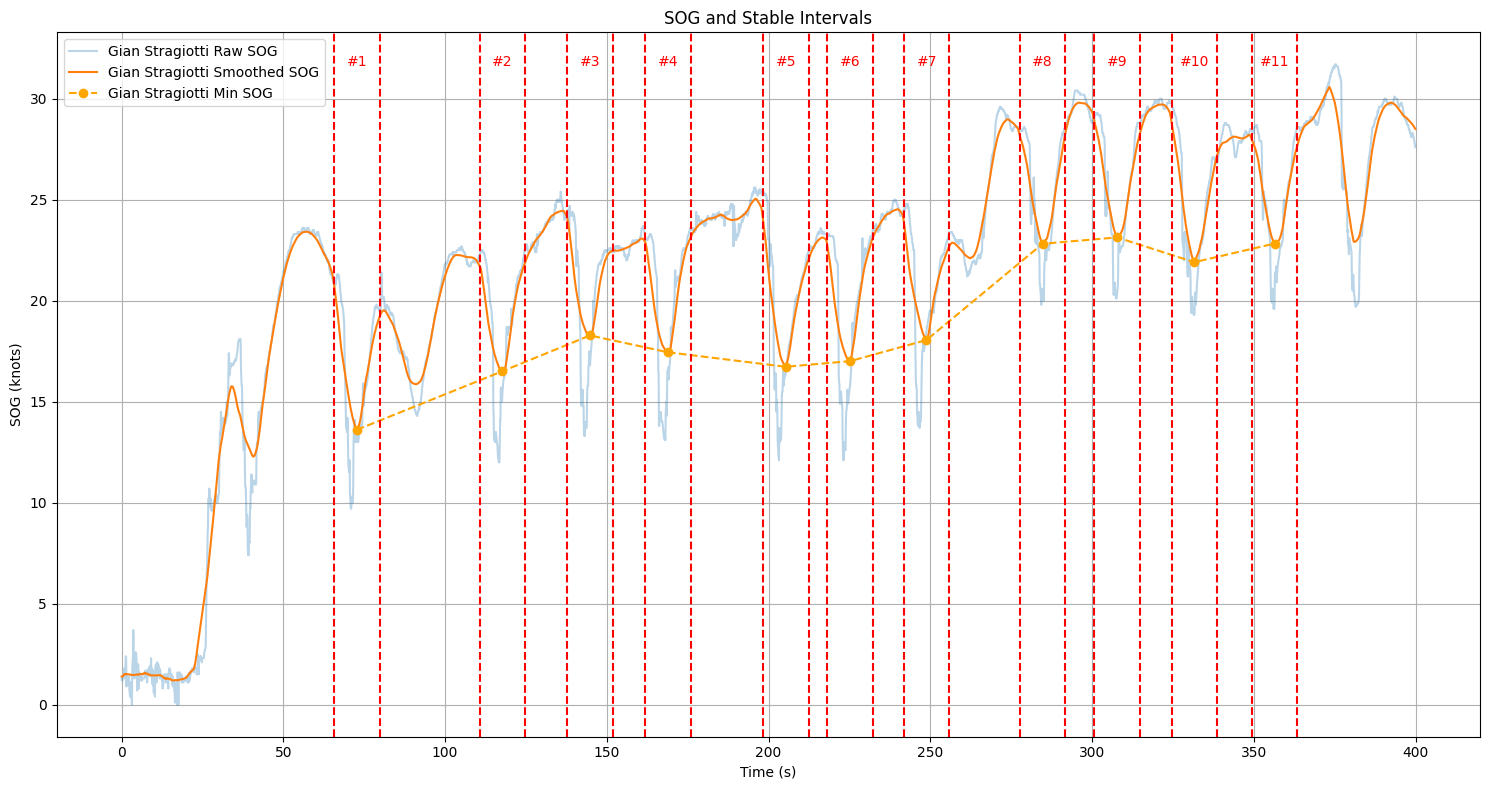

Skipped 1 maneuver(s) in Gian/30_11_2025_Run11: indices: [1]
Initial number of maneuvers: 11
Number of maneuvers selected: 10 






../Data_Sailnjord/Hyères November 2025/Maneuvers\30_11_2025\Gian\30_11_2025_Run12


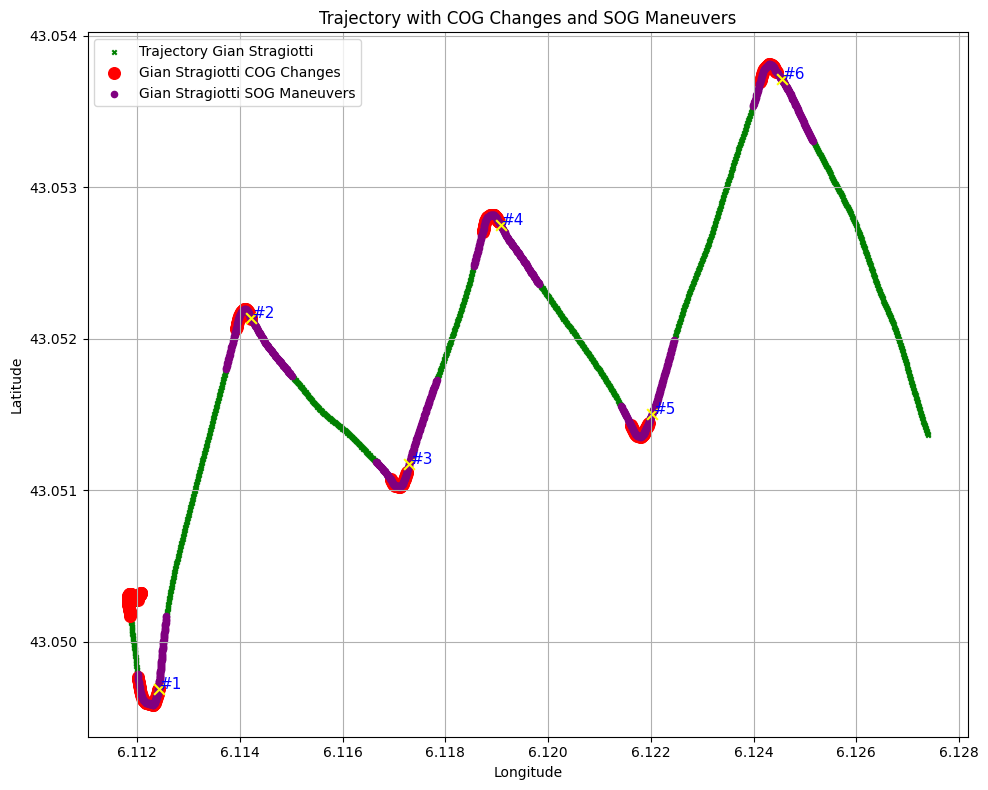

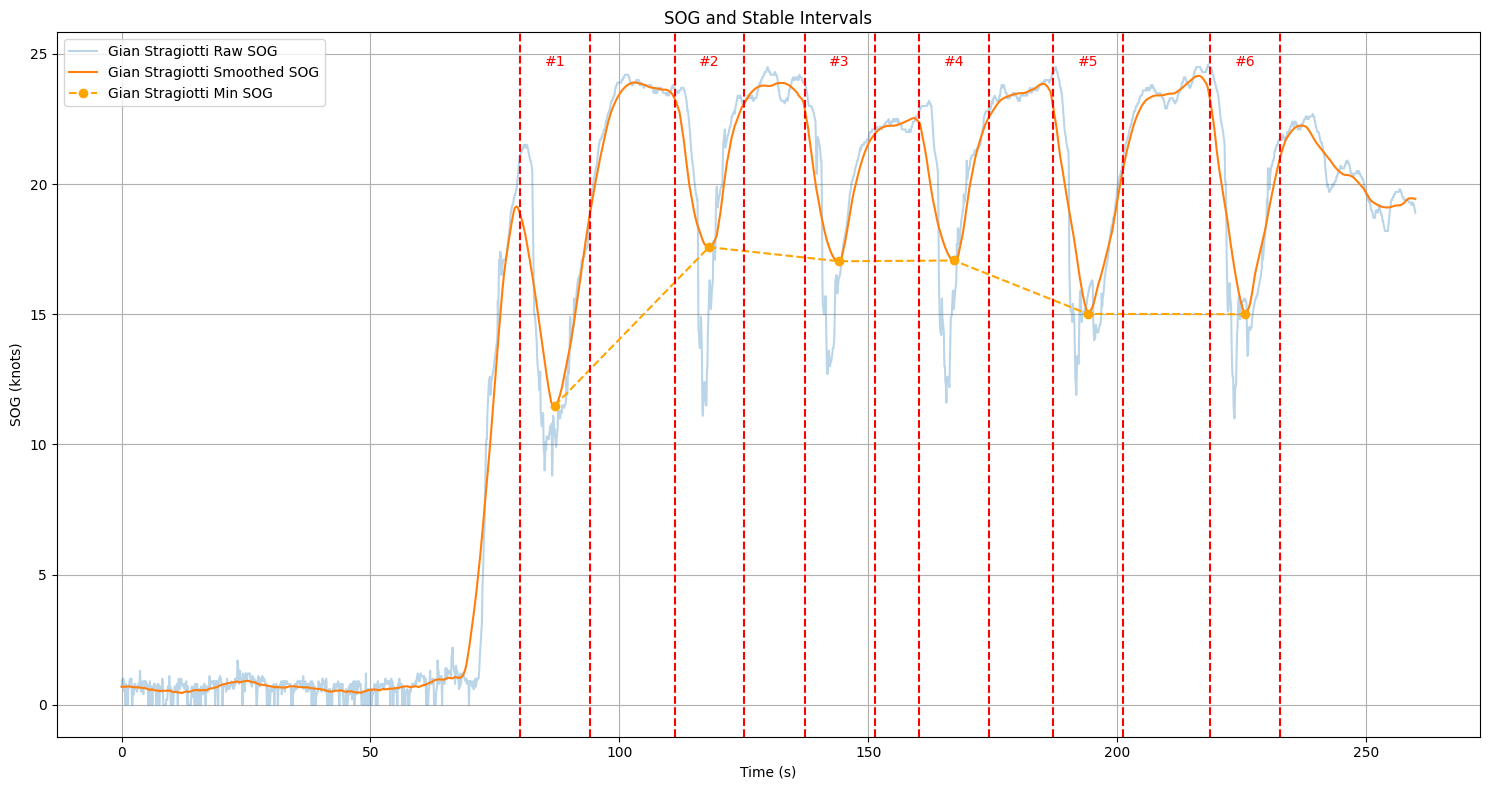

Skipped 1 maneuver(s) in Gian/30_11_2025_Run12: indices: [1]
Initial number of maneuvers: 6
Number of maneuvers selected: 5 






Résumé complet sauvegardé (2 runs)


In [1]:
import os
import json
from cog_analysis import analyze_session
from natsort import natsorted

summary = []

# Format: { "person/run": [maneuver_index_to_skip, ...] }
'''
manual_skips = {
    "Gian/08_06_2025_Run1": [7,14],
    "Gian/08_06_2025_Run2": [1,8,14],
    "Gian/08_06_2025_Run3": [1,8,14],
    "Gian/08_06_2025_Run4": [5,12],
    "Gian/08_06_2025_Run5": [1,13],
    "Karl/08_06_2025_Run1": [8],
    "Karl/08_06_2025_Run2": [12],
    "Karl/08_06_2025_Run3": [13],
    "Karl/08_06_2025_Run4": [6],
    "Karl/08_06_2025_Run5": [12],
    "Gian/11_06_2025_Run1": [7,14],
    "Gian/11_06_2025_Run2": [7,13],
    "Gian/11_06_2025_Run3": [7,14],
    "Gian/11_06_2025_Run4": [1,7,14],
    "Gian/11_06_2025_Run5": [7,13],
    "Karl/11_06_2025_Run1": [7],
    "Karl/11_06_2025_Run2": [1,8],
    "Karl/11_06_2025_Run3": [7],
    "Karl/11_06_2025_Run4": [5,6,13],
    "Karl/11_06_2025_Run5": [7,14],
    "Karl/11_06_2025_Run6": [7]
    #exluding only hand-picked maneuvers
    #"Gian/08_06_2025_Run2": [1],
    #"Gian/08_06_2025_Run3": [1],
    #"Gian/08_06_2025_Run5": [1],
    #"Gian/11_06_2025_Run4": [1],
    #"Karl/11_06_2025_Run2": [1],
    #"Karl/11_06_2025_Run4": [5]
}
'''
manual_skips = {"Gian/30_11_2025_Run11": [1], "Gian/30_11_2025_Run12": [1]}
# base_dir = "../Data_Sailnjord/Maneuvers"
# base_dir = "../Data_Sailnjord/Port Camargue June 2025/Maneuvers"
base_dir = "../Data_Sailnjord/Hyères November 2025/Maneuvers"
# Parcours tous les dossiers de date
for date_folder in sorted(os.listdir(base_dir)):
    date_path = os.path.join(base_dir, date_folder)
    for person_folder in sorted(os.listdir(date_path)):
        person_path = os.path.join(date_path, person_folder)
        for run_folder in natsorted(os.listdir(person_path)):
            if person_folder == "Interview and equipment":
                continue  # Skip interview folder
            run_path = os.path.join(person_path, run_folder)
            print(run_path)
            csv_files = [f for f in os.listdir(run_path) if f.endswith(".csv")]
            csv_path = os.path.join(run_path, csv_files[0])
            intervals = analyze_session(
                    boat1_path=csv_path, 
                    boat2_path=None, 
                    cog_threshold=30.0, # detect_COG_changes_rolling_mean
                    window=30,  #detect_COG_changes_rolling_mean

                    sog_smoothing_window=75, #detect_maneuvers_from_sog_minima
                    sog_prominence=2, #detect_maneuvers_from_sog_minima
                    sog_min_duration=10.0, #detect_maneuvers_from_sog_minima
                    twa_threshold=90.0, #detect_maneuvers_from_sog_minima
                    cog_inversion_threshold=45.0, #detect_maneuvers_from_sog_minima
                    min_minima_distance=12.0, #detect_maneuvers_from_sog_minima
                    pre_window = 7.0, 
                    post_window = 7.0,
                    min_sog_entry_threshold = 18.0,

                    #Following parameters useless for maneuvers (only used when there is 2 boats to wompare)
                    top_n_intervals=2, # compute_longest_intervals 
                    min_duration_sec=40.0, #compute_longest_intervals
                    sog_derivative_threshold=0.3, #compute_longest_intervals
                    smoothing_window=100  #compute_longest_intervals
                )

            # Build key for skipping
            run_id = f"{person_folder}/{run_folder}"

            # Apply manual skip filter
            if run_id in manual_skips:
                to_skip = manual_skips[run_id]
                original_intervals = intervals.copy()
                skipped = [m for m in original_intervals if m.get("maneuver_index") in to_skip]
                intervals = [m for m in original_intervals if m.get("maneuver_index") not in to_skip]
                if skipped:
                    skipped_str = ", ".join(str(m["maneuver_index"]) for m in skipped)
                    print(f"Skipped {len(skipped)} maneuver(s) in {run_id}: indices: [{skipped_str}]")
                    print(f"Initial number of maneuvers: {len(original_intervals)}")


            print(f"Number of maneuvers selected: {len(intervals)} \n\n\n\n\n\n")
            
            summary.append({
                "date": date_folder,
                "person": person_folder,
                "run": run_folder,
                "intervals": intervals
            })



# Sauvegarde du résumé
summary_file = "summary.json"
with open(summary_file, "w") as f:
    json.dump(summary, f, indent=2)

print(f"Résumé complet sauvegardé ({len(summary)} runs)")


In [2]:
print(json.dumps(summary, indent=2))

[
  {
    "date": "30_11_2025",
    "person": "Gian",
    "run": "30_11_2025_Run11",
    "intervals": [
      {
        "maneuver_index": 2,
        "maneuver_time": 1764505557.654,
        "maneuver_type": "Tack",
        "duration": 14.0,
        "start_time": 1764505550.757,
        "end_time": 1764505564.757
      },
      {
        "maneuver_index": 3,
        "maneuver_time": 1764505584.852,
        "maneuver_type": "Tack",
        "duration": 14.105000019073486,
        "start_time": 1764505577.854,
        "end_time": 1764505591.959
      },
      {
        "maneuver_index": 4,
        "maneuver_time": 1764505608.956,
        "maneuver_type": "Tack",
        "duration": 14.000999927520752,
        "start_time": 1764505601.956,
        "end_time": 1764505615.957
      },
      {
        "maneuver_index": 5,
        "maneuver_time": 1764505645.36,
        "maneuver_type": "Tack",
        "duration": 13.999000072479248,
        "start_time": 1764505638.454,
        "end_time": 176